In [1]:
import numpy as np
from tools import *
from ts2vec.ts2vec import TS2Vec
import torch
import umap
import matplotlib.pyplot as plt

2025-12-09 01:53:36.938487: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765241616.957030 1419067 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765241616.962832 1419067 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-09 01:53:36.983380: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


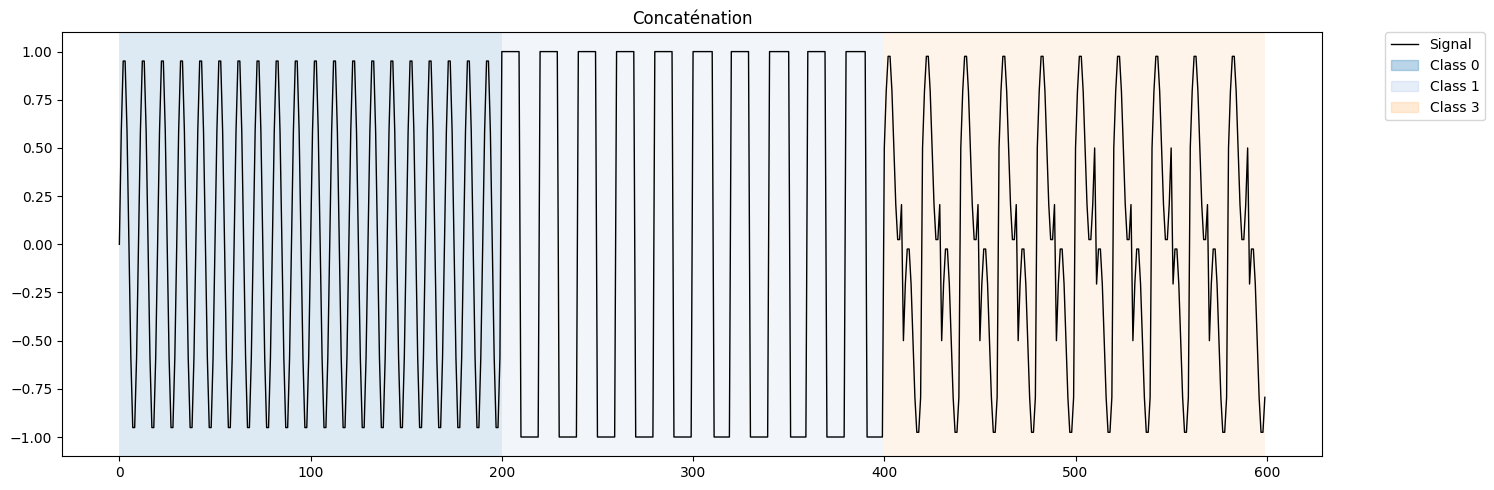

In [2]:
gen = ToyGenerator()

# 1. Deux signaux distincts
ds_sin = gen.generate(type='sine', length=200)   # ID = 0 (Bleu)
ds_sq  = gen.generate(type='square', length=200) # ID = 1 (Orange) -> Incrémentation auto !

# 2. Concaténation simple (Doit montrer Classe 0 puis Classe 1)
ds_concat = ToyDataset.concat([ds_sin, ds_sq])

# 3. Mélange complexe (Somme)
# Comme on mélange ds_sin (0) et ds_sq (1), le résultat aura un NOUVEL ID (2)
ds_mix = (ds_sin + ds_sq )/2

# 4. Concaténation imbriquée
# On met bout à bout : [Sinus] -> [Carré] -> [Mélange]
# Labels attendus : [0, 0... 1, 1... 2, 2...]
ds_final = ToyDataset.concat([ds_concat, ds_mix])

plot_toy_dataset(ds_final, title="Concaténation")

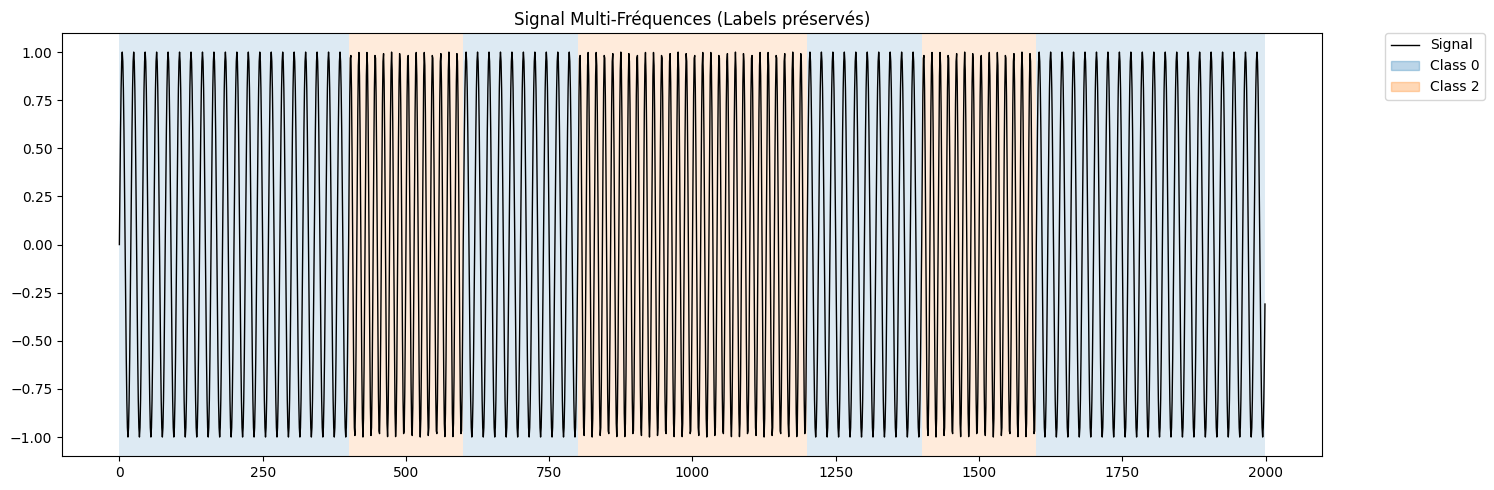

Labels uniques dans y_train: [0 1 2]
sapes of train and test sets: (99, 1000, 1) (24, 1000, 1)


In [3]:
# 1. Setup
gen = ToyGenerator()
sequencer = TimeSeriesSequencer(gen)

# 2. Configs
atom_configs = [
    # Classe 0 (Freq 0.05)
    {'type': 'sine', 'params': {'freq': 0.05, 'amp': 1.0}, 'prob': 0.4, 'duration_mean': 200},
    # Classe 1 (Freq 0.02)
    {'type': 'sine', 'params': {'freq': 0.02, 'amp': 1.0}, 'prob': 0.3, 'duration_mean': 200},
    # Classe 2 (Freq 0.07)
    {'type': 'sine', 'params': {'freq': 0.07, 'amp': 1.0}, 'prob': 0.3, 'duration_mean': 200},
]

# 3. Génération
long_ds = sequencer.generate_sequence(atom_configs, total_length=100000, sequencing='random')

# 4. Perturbations
# ATTENTION : Ne pas faire "long_ds = long_ds + bruit" sinon vous perdez les classes !
# Utilisez la méthode add_noise qu'on vient de créer ou modifiez .data directement
long_ds.add_noise(noise_std=0.0)

# Le reste des perturbations (outliers/missing) ne change pas les classes
long_ds = gen.apply_perturbations(long_ds, outlier_ratio=0.0, missing_ratio=0.0)

# 5. Visualisation
# Vous devriez voir 3 couleurs de fond distinctes qui alternent
plot_toy_dataset(long_ds[0:2000], title="Signal Multi-Fréquences (Labels préservés)")

# 6. Output TS2Vec
X_train, y_train, X_test, y_test = sequencer.make_ts2vec_input(
    long_ds, window_size=1000, stride=800, split_ratio=0.8
)

# y_test contient maintenant les labels 0, 1, 2 correspondants aux fréquences !
print("Labels uniques dans y_train:", np.unique(y_train))
print("sapes of train and test sets:", X_train.shape, X_test.shape)

In [4]:
# --- 1. Vérification des dimensions ---
# TS2Vec attend (Batch, Time, Features). Si vos données sont (Batch, Time), on ajoute la dim Features.
if X_train.ndim == 2:
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

print(f"Format final pour TS2Vec: {X_train.shape}")


Format final pour TS2Vec: (99, 1000, 1)


In [5]:
# --- 2. Initialisation et Entraînement ---
# On utilise un 'input_dims=1' car c'est une série univariée
model = TS2Vec(
    input_dims=1,
    output_dims = 320,
    hidden_dims = 64,
    depth= 10,
    device = 'cuda' if torch.cuda.is_available() else 'cpu',
    lr = 0.001,
    batch_size = 16,
    max_train_length = 500,
    temporal_unit = 0,
    after_iter_callback = None,
    after_epoch_callback = None
)

print("Démarrage de l'entraînement TS2Vec...")
# Note : y_train n'est PAS utilisé ici. C'est de l'apprentissage auto-supervisé.
loss_log = model.fit(
    X_train,
    verbose=True,
    n_epochs=15 # 50 époques suffisent souvent pour ce genre de toy dataset
)

Démarrage de l'entraînement TS2Vec...


/home/infres/kberlivet-23/miniconda3/envs/main_kilian_3.10/lib/python3.10/site-packages/torch/nn/modules/conv.py:309: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv1d(input, weight, bias, self.stride,


Epoch #0: loss=4.223801930745442
Epoch #1: loss=2.9501662453015647
Epoch #2: loss=2.5959085822105408
Epoch #3: loss=2.3656771381696067
Epoch #4: loss=2.1287138362725577
Epoch #5: loss=1.967522402604421
Epoch #6: loss=1.8536550899346669
Epoch #7: loss=2.033552954594294
Epoch #8: loss=1.8820343315601349
Epoch #9: loss=1.764189253250758
Epoch #10: loss=1.6182499825954437
Epoch #11: loss=1.627776066462199
Epoch #12: loss=1.5759767889976501
Epoch #13: loss=1.6044247945149739
Epoch #14: loss=1.5201452275117238


In [6]:
# --- 3. Encodage et Réduction (Inférence) ---
print("Encodage des données de test...")
# On récupère la représentation (Batch, Time, 320)
test_repr = model.encode(X_test, )
print(f"Représentation encodée TS2Vec: {test_repr.shape}")
print(f"labels y_test: {y_test.shape}")

#concatenation of all time steps
test_repr_concat = test_repr.reshape(-1, test_repr.shape[-1])
print(f"Représentation concaténée: {test_repr_concat.shape}")
#same for labels
y_test_concat = y_test.reshape(-1)
print(f"Labels concaténés: {y_test_concat.shape}")

Encodage des données de test...
Représentation encodée TS2Vec: (24, 1000, 320)
labels y_test: (24, 1000)
Représentation concaténée: (24000, 320)
Labels concaténés: (24000,)


In [7]:
import plotly.express as px
import pandas as pd


In [8]:
# On fait la moyenne sur l'axe temporel pour avoir 1 vecteur par fenêtre
# (Batch, Time, 320) -> (Batch, 320)


print("Calcul de la projection UMAP...")
reducer = umap.UMAP(n_components=3, random_state=42,metric='cosine')
embedding = reducer.fit_transform(test_repr_concat)

Calcul de la projection UMAP...


/home/infres/kberlivet-23/miniconda3/envs/main_kilian_3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [9]:

# 1. Create a clean DataFrame for Plotly
df_plot = pd.DataFrame(embedding, columns=['Dim1', 'Dim2', 'Dim3'])

# Map your labels to names for the legend
class_names = {0: 'Classe 0 (Freq 0.05)', 1: 'Classe 1 (Freq 0.02)', 2: 'Classe 2 (Freq 0.07)'}
df_plot['Label'] = [class_names[y] for y in y_test_concat]

# 2. Create the interactive 3D plot
fig = px.scatter_3d(
    df_plot,
    x='Dim1',
    y='Dim2',
    z='Dim3',
    color='Label',
    title='Espace Latent TS2Vec (UMAP 3D) COSINE',
    opacity=0.7,
    width=1000,
    height=800
)

# Make the dots smaller (like s=20 in matplotlib)
fig.update_traces(marker=dict(size=3))

fig.show()

In [10]:
# On fait la moyenne sur l'axe temporel pour avoir 1 vecteur par fenêtre
# (Batch, Time, 320) -> (Batch, 320)


print("Calcul de la projection UMAP...")
reducer = umap.UMAP(n_components=3, random_state=42,metric='euclidean')
embedding = reducer.fit_transform(test_repr_concat)

Calcul de la projection UMAP...


/home/infres/kberlivet-23/miniconda3/envs/main_kilian_3.10/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [11]:

# 1. Create a clean DataFrame for Plotly
df_plot = pd.DataFrame(embedding, columns=['Dim1', 'Dim2', 'Dim3'])

# Map your labels to names for the legend
class_names = {0: 'Classe 0 (Freq 0.05)', 1: 'Classe 1 (Freq 0.02)', 2: 'Classe 2 (Freq 0.07)'}
df_plot['Label'] = [class_names[y] for y in y_test_concat]

# 2. Create the interactive 3D plot
fig = px.scatter_3d(
    df_plot,
    x='Dim1',
    y='Dim2',
    z='Dim3',
    color='Label',
    title='Espace Latent TS2Vec (UMAP 3D) EUCLIDEAN',
    opacity=0.7,
    width=1000,
    height=800
)

# Make the dots smaller (like s=20 in matplotlib)
fig.update_traces(marker=dict(size=3))

fig.show()

In [12]:
from sklearn.decomposition import PCA

In [13]:
# on fait un PCA avec les classes réelles
# --- 2. Calcul de la PCA ---
X_pca_input = test_repr_concat  # Utilisation des représentations TS2Vec
n_components = 4  # On calcule les 4 premières, on affichera les 2 principales
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_pca_input)

# Calcul des pourcentages de variance expliquée (pour savoir si la PCA est fiable)
var_ratio = pca.explained_variance_ratio_

print(f"Variance expliquée par les {n_components} premières composantes : {var_ratio}")
print(f"Variance cumulée (info totale gardée) : {np.sum(var_ratio):.2%}")

# --- 3. Visualisation (PC1 vs PC2) ---
plt.figure(figsize=(10, 8))

# Définition des noms de classes (si identique à avant)
class_names = {0: 'Classe 0 (0.05)', 1: 'Classe 1 (0.02)', 2: 'Classe 2 (0.07)'}
df_pca = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])

# Ajout des labels lisibles
df_pca['Classe'] = [class_names.get(c, str(c)) for c in y_test_concat]

# Création du graphe
fig = px.scatter_3d(
    df_pca,
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Classe',
    title=f'PCA 3D Interactive (Variance Totale: {np.sum(var_ratio):.2%})',
    opacity=0.7,
    width=1000,
    height=800,
    labels={
        'PC1': f'PC1 ({var_ratio[0]:.2%})',
        'PC2': f'PC2 ({var_ratio[1]:.2%})',
        'PC3': f'PC3 ({var_ratio[2]:.2%})'
    }
)

fig.update_traces(marker=dict(size=3)) # Taille des points
fig.show()

Variance expliquée par les 4 premières composantes : [0.21395212 0.21207522 0.13732888 0.12309783]
Variance cumulée (info totale gardée) : 68.65%


<Figure size 1000x800 with 0 Axes>

In [14]:
import matplotlib.patches as mpatches

In [15]:
def plot_ts_representation(ts_data, embedding_data, labels, class_names=None, title="Série Temporelle & Représentation Latente"):
    """
    ts_data        : array (T,) ou (T, D) - La série temporelle brute
    embedding_data : array (T, F) - La représentation (embedding) par timestamp
    labels         : array (T,) - Les labels par timestamp
    class_names    : dict - Mapping {0: 'Nom', ...} pour la légende
    """
    
    # 1. Configuration de la figure (2 sous-graphiques partagent l'axe X)
    fig, (ax_ts, ax_emb) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, 
                                        gridspec_kw={'height_ratios': [1, 1.5]})
    
    # --- GRAPHIQUE 1 : SÉRIE TEMPORELLE (HAUT) ---
    ax_ts.plot(ts_data, color='black', linewidth=1.5, label='Signal')
    ax_ts.set_title(title, fontsize=14, fontweight='bold')
    ax_ts.set_ylabel("Amplitude")
    
    # Détection des changements de labels pour colorier le fond
    # On trouve les indices où le label change
    change_points = np.where(np.diff(labels) != 0)[0] + 1
    # On ajoute 0 et la fin pour boucler correctement
    boundaries = np.concatenate(([0], change_points, [len(labels)]))
    
    # Palette de couleurs pour les zones (fond)
    unique_labels = np.unique(labels)
    cmap_zones = plt.get_cmap('Pastel1', len(unique_labels)) # Couleurs douces pour le fond
    
    # Dictionnaire pour garder une seule entrée de légende par classe
    legend_patches = {}

    for i in range(len(boundaries) - 1):
        start, end = boundaries[i], boundaries[i+1]
        current_label = labels[start]
        
        # Récupération couleur et nom
        color = cmap_zones(current_label % len(unique_labels)) # Modulo pour éviter erreur si bcp classes
        label_name = class_names[current_label] if class_names else f"Classe {current_label}"
        
        # Colorer le fond (axvspan)
        ax_ts.axvspan(start, end, color=color, alpha=0.5, lw=0)
        
        # Stocker pour la légende
        if current_label not in legend_patches:
            legend_patches[current_label] = mpatches.Patch(color=color, label=label_name)

    # Légende personnalisée pour les zones
    ax_ts.legend(handles=list(legend_patches.values()), loc='upper right')
    
    # --- GRAPHIQUE 2 : REPRÉSENTATION / EMBEDDING (BAS) ---
    # On transpose l'embedding pour avoir (Features, Time)
    # aspect='auto' est CRUCIAL pour que l'image s'étire sur toute la largeur temporelle
    im = ax_emb.imshow(embedding_data.T, aspect='auto', cmap='viridis', origin='lower')
    
    ax_emb.set_ylabel("Dimensions Latentes (Features)")
    ax_emb.set_xlabel("Temps (Time steps)")
    
    # Ajout des pointillés verticaux aux changements de classe
    for cp in change_points:
        # Ligne pointillée blanche (ou rouge) verticale
        ax_emb.axvline(x=cp, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # Barre de couleur pour l'intensité des features
    cbar = plt.colorbar(im, ax=ax_emb, orientation='horizontal', fraction=0.05, pad=0.2)
    cbar.set_label('Valeur d\'activation des neurones')

    plt.tight_layout()
    plt.show()

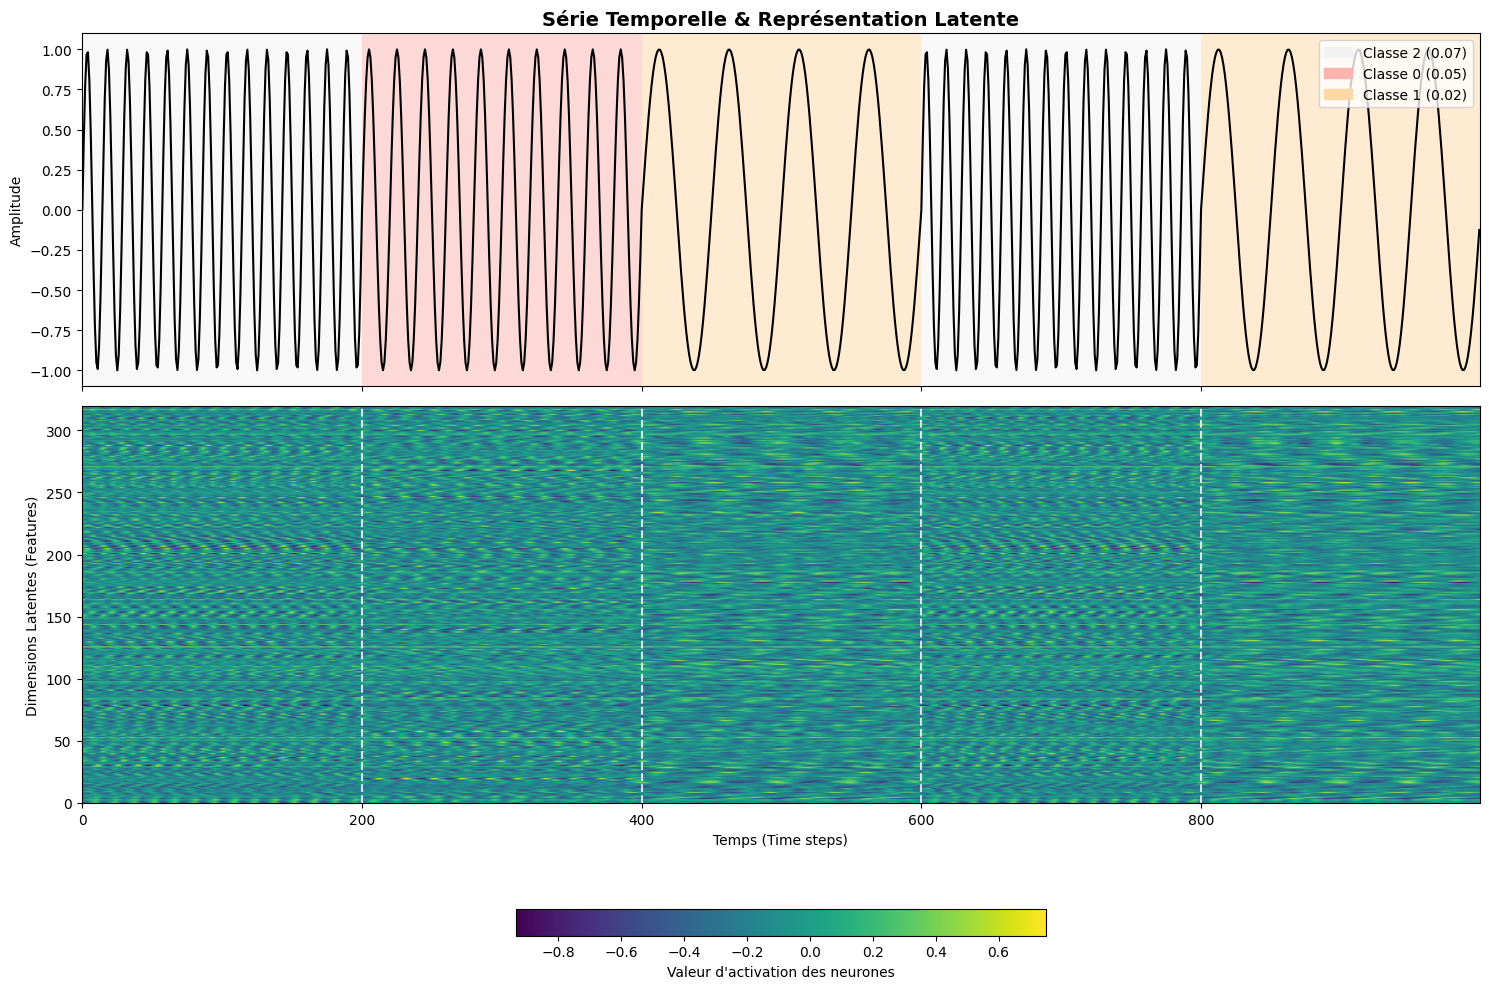

In [19]:
# Supposons que tu veuilles voir la séquence numéro 10 de ton set de test
i=2

# Récupération des données (adapter selon le format de tes tenseurs)
# Si X_test est (N, T, D) et test_repr est (N, T, F)
# Attention : assure-toi que les dimensions correspondent à une seule séquence temporelle
ts_sample = X_test[i]  
emb_sample = test_repr[i]
lbl_sample = y_test[i]

# Astuce : Si tes données sont trop longues (tout le concat), prends juste les 1000 premiers points
# pour que ce soit lisible :
limit = len(ts_sample)  # Mettre une limite ici si besoin
ts_zoom = ts_sample[:limit]
emb_zoom = emb_sample[:limit]
lbl_zoom = lbl_sample[:limit]

class_names = {0: 'Classe 0 (0.05)', 1: 'Classe 1 (0.02)', 2: 'Classe 2 (0.07)'}

plot_ts_representation(ts_zoom, emb_zoom, lbl_zoom, class_names)